In [28]:
import urllib.request

url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
file_name = "shape_predictor_68_face_landmarks.dat.bz2"

if not os.path.exists("shape_predictor_68_face_landmarks.dat"):
    print("Downloading landmark model...")

    urllib.request.urlretrieve(url, file_name)

    import bz2

    with bz2.BZ2File(file_name) as fr, open("shape_predictor_68_face_landmarks.dat", "wb") as fw:
        fw.write(fr.read())

    print("Model downloaded and extracted.")

Dataset Path: repo/facial_recognition-main/processed_data
Total images: 54


100%|██████████| 54/54 [00:03<00:00, 14.69it/s]


Train: 33
Val: 11
Test: 10

Saved: face_embeddings.npz

Failed images: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Sample Pipeline Results:


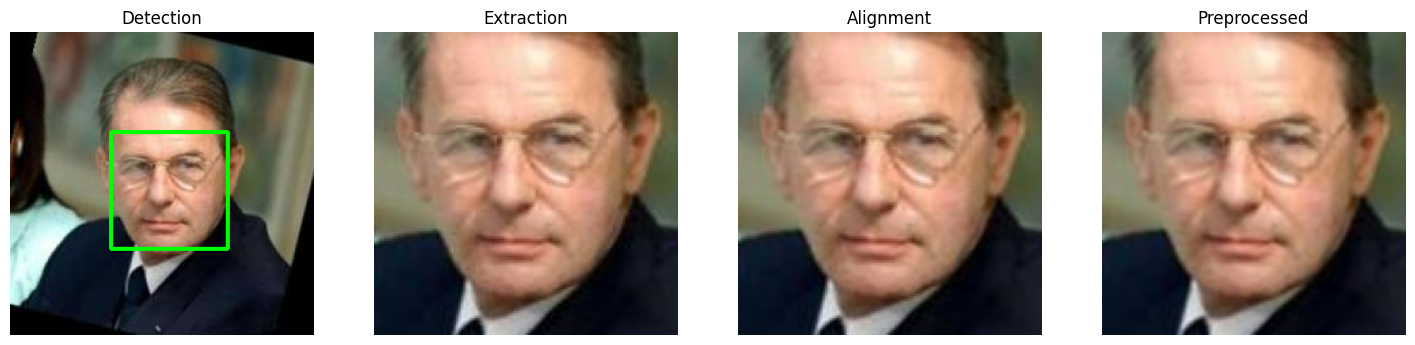

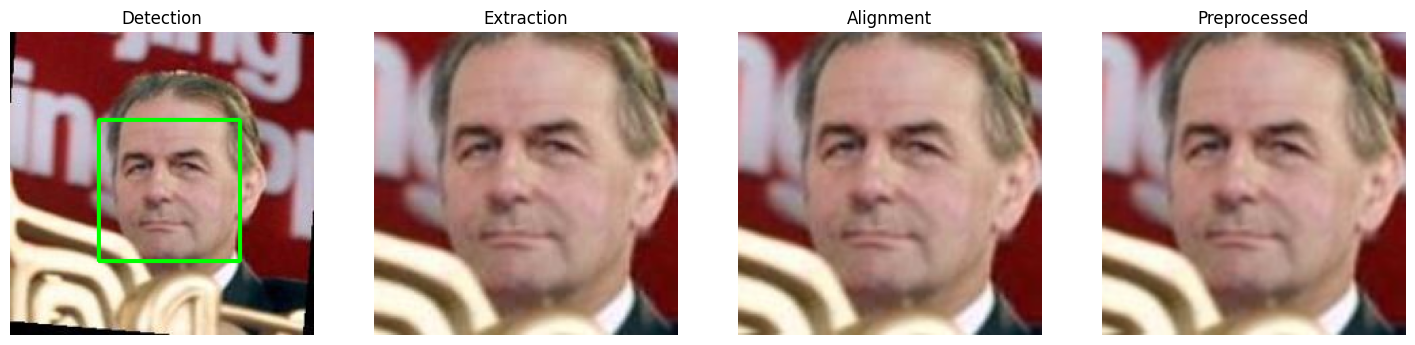

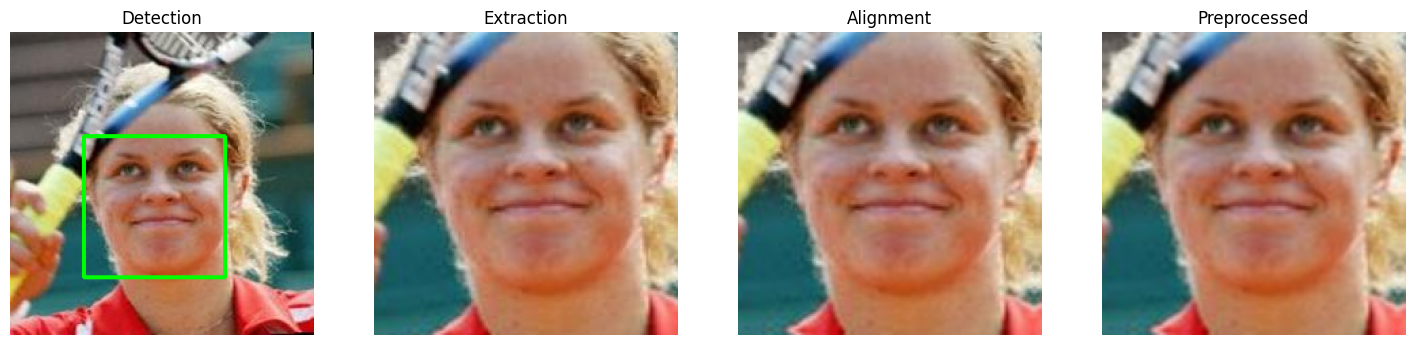

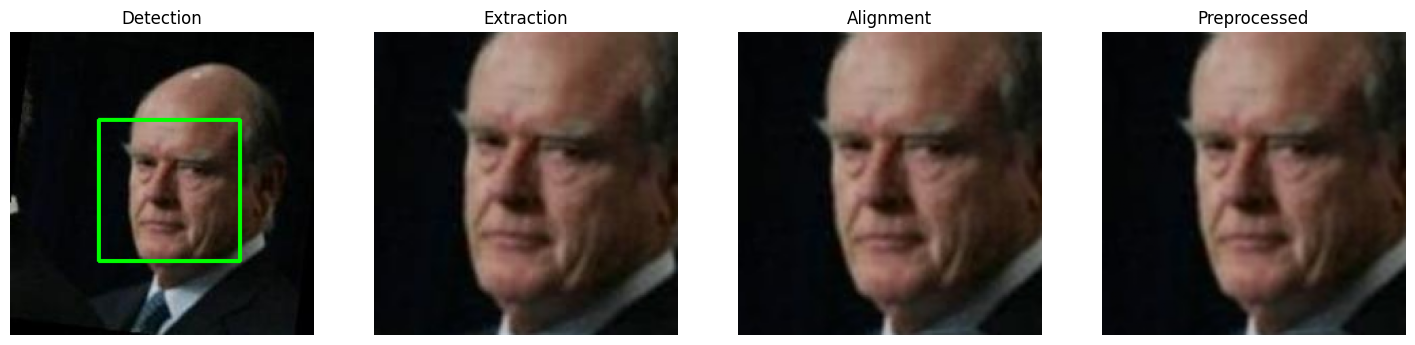

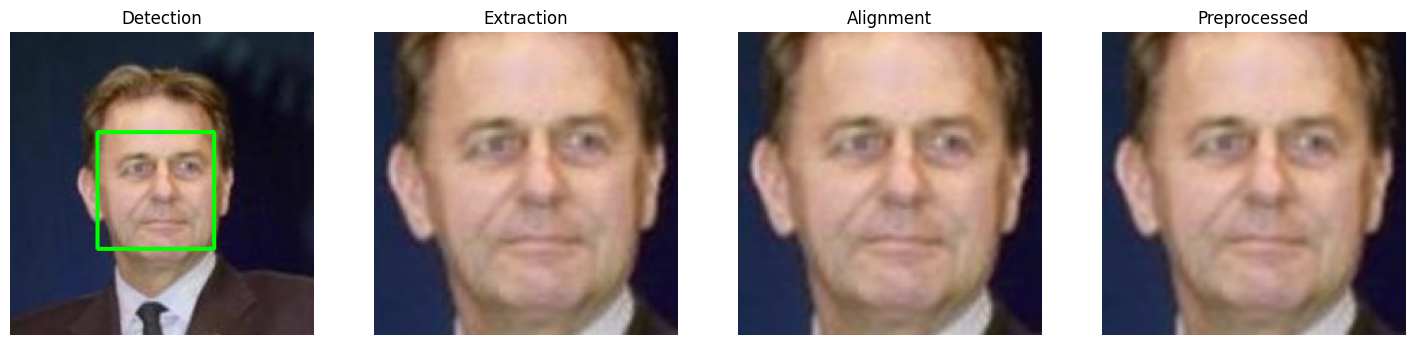

In [29]:
# ==========================================================
# DELIVERABLE 2 - FACE PIPELINE (FINAL CLEAN VERSION)
# Detection → Extraction → Alignment → Preprocessing → Embeddings
# ==========================================================

# -------------------------------
# INSTALL DEPENDENCIES
# -------------------------------
!pip install opencv-python dlib matplotlib tqdm face_recognition requests

# -------------------------------
# IMPORT LIBRARIES
# -------------------------------
import os
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import face_recognition
import shutil
import random
import requests
from zipfile import ZipFile

# -------------------------------
# REPRODUCIBILITY
# -------------------------------
random.seed(42)
np.random.seed(42)

# ==========================================================
# SETTINGS
# ==========================================================
github_repo_zip_url = "https://github.com/Nayanapmku/facial_recognition/archive/refs/heads/main.zip"

input_root = "processed_data"
output_dir = "preprocess_aligned"
embedding_file = "face_embeddings.npz"

IMG_SIZE = 224
NUM_SAMPLES = 5

# ==========================================================
# LOAD DATASET
# ==========================================================
if not os.path.exists(input_root):
    print("Downloading dataset...")

    r = requests.get(github_repo_zip_url, stream=True)
    with open("repo.zip", "wb") as f:
        for chunk in r.iter_content(1024):
            f.write(chunk)

    with ZipFile("repo.zip", "r") as zip_ref:
        zip_ref.extractall("repo")

    for root, dirs, files in os.walk("repo"):
        if input_root in dirs:
            input_root = os.path.join(root, input_root)
            break

print("Dataset Path:", input_root)

# ==========================================================
# MODELS
# ==========================================================
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

# ==========================================================
# FACE DETECTION
# ==========================================================
def detect_faces(img):
    return detector(img)

# ==========================================================
# FACE EXTRACTION
# ==========================================================
def extract_face(img, rect, pad=20):
    x1 = max(rect.left() - pad, 0)
    y1 = max(rect.top() - pad, 0)
    x2 = min(rect.right() + pad, img.shape[1])
    y2 = min(rect.bottom() + pad, img.shape[0])

    face = img[y1:y2, x1:x2]
    return face if face.size != 0 else None

# ==========================================================
# FACE ALIGNMENT
# ==========================================================
def align_face(face_img):
    try:
        gray = cv2.cvtColor(face_img, cv2.COLOR_RGB2GRAY)
        rect = dlib.rectangle(0, 0, face_img.shape[1], face_img.shape[0])
        landmarks = predictor(gray, rect)

        left_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(36,42)], axis=0)
        right_eye = np.mean([(landmarks.part(i).x, landmarks.part(i).y) for i in range(42,48)], axis=0)

        dx = right_eye[0] - left_eye[0]
        dy = right_eye[1] - left_eye[1]
        angle = np.degrees(np.arctan2(dy, dx))

        eyes_center = ((left_eye[0] + right_eye[0]) / 2,
                       (left_eye[1] + right_eye[1]) / 2)

        M = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)

        aligned = cv2.warpAffine(
            face_img,
            M,
            (face_img.shape[1], face_img.shape[0]),
            flags=cv2.INTER_CUBIC,
            borderMode=cv2.BORDER_REFLECT
        )

        return aligned

    except:
        return None

# ==========================================================
# PREPROCESSING (RGB + 224x224)
# ==========================================================
def preprocess(img):
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0

    return img

# ==========================================================
# SAVE IMAGE
# ==========================================================
def save_image(img, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.imsave(path, (img * 255).astype(np.uint8))

# ==========================================================
# EMBEDDINGS
# ==========================================================
def get_embedding(img):
    img_uint8 = (img * 255).astype(np.uint8)
    enc = face_recognition.face_encodings(img_uint8)
    return enc[0] if len(enc) > 0 else None

# ==========================================================
# LOAD ALL IMAGES
# ==========================================================
image_paths = []
for root, dirs, files in os.walk(input_root):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, f))

print("Total images:", len(image_paths))

# ==========================================================
# STORAGE
# ==========================================================
embeddings = {
    "train_embeddings": [], "train_labels": [],
    "val_embeddings": [], "val_labels": [],
    "test_embeddings": [], "test_labels": []
}

train_paths, val_paths, test_paths = [], [], []

failed = []

# ==========================================================
# MAIN PIPELINE
# ==========================================================
for img_path in tqdm(image_paths):

    img = cv2.imread(img_path)
    if img is None:
        failed.append((img_path, "read failed"))
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        failed.append((img_path, "no face"))
        continue

    face = extract_face(img_rgb, faces[0])
    if face is None:
        failed.append((img_path, "crop failed"))
        continue

    aligned = align_face(face)
    if aligned is None:
        failed.append((img_path, "alignment failed"))
        continue

    processed = preprocess(aligned)
    if processed is None:
        failed.append((img_path, "preprocess failed"))
        continue

    # SAVE IMAGE
    rel_path = img_path.replace(input_root, "").lstrip("/")
    save_image(processed, os.path.join(output_dir, rel_path))

    # EMBEDDING
    emb = get_embedding(processed)
    if emb is None:
        failed.append((img_path, "embedding failed"))
        continue

    label = os.path.basename(os.path.dirname(img_path))

    # ======================================================
    # ROBUST DATASET SPLIT DETECTION (FIXED)
    # ======================================================
    path_lower = img_path.replace("\\", "/").lower()

    if "train" in path_lower:
        embeddings["train_embeddings"].append(emb)
        embeddings["train_labels"].append(label)
        train_paths.append(img_path)

    elif "val" in path_lower:
        embeddings["val_embeddings"].append(emb)
        embeddings["val_labels"].append(label)
        val_paths.append(img_path)

    elif "test" in path_lower:
        embeddings["test_embeddings"].append(emb)
        embeddings["test_labels"].append(label)
        test_paths.append(img_path)

# ==========================================================
# DEBUG CHECK (IMPORTANT)
# ==========================================================
print("\nTrain:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

# Prevent empty dataset crash
assert len(train_paths) > 0, "Train set empty"
assert len(val_paths) > 0, "Val set empty"
assert len(test_paths) > 0, "Test set empty"

# ==========================================================
# SAVE EMBEDDINGS + PATHS
# ==========================================================
np.savez(
    embedding_file,

    train_embeddings=np.array(embeddings["train_embeddings"]),
    train_labels=np.array(embeddings["train_labels"]),
    train_paths=np.array(train_paths),

    val_embeddings=np.array(embeddings["val_embeddings"]),
    val_labels=np.array(embeddings["val_labels"]),
    val_paths=np.array(val_paths),

    test_embeddings=np.array(embeddings["test_embeddings"]),
    test_labels=np.array(embeddings["test_labels"]),
    test_paths=np.array(test_paths)
)

print("\nSaved:", embedding_file)

# ==========================================================
# FAILURE REPORT
# ==========================================================
print("\nFailed images:", len(failed))
for f in failed[:10]:
    print(f)

# ==========================================================
# ZIP OUTPUT
# ==========================================================
shutil.make_archive(output_dir, "zip", output_dir)

from google.colab import files
files.download(output_dir + ".zip")
files.download(embedding_file)

# ==========================================================
# VISUALIZATION (REQUIRED FOR DELIVERABLE)
# ==========================================================
def visualize_pipeline(img_path):

    img = cv2.imread(img_path)
    if img is None:
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    faces = detect_faces(img_rgb)
    if len(faces) == 0:
        return

    rect = faces[0]

    # Original with box
    img_box = img_rgb.copy()
    cv2.rectangle(
        img_box,
        (rect.left(), rect.top()),
        (rect.right(), rect.bottom()),
        (0,255,0), 2
    )

    face = extract_face(img_rgb, rect)
    aligned = align_face(face)
    processed = preprocess(aligned)

    fig, ax = plt.subplots(1,4, figsize=(18,5))

    ax[0].imshow(img_box)
    ax[0].set_title("Detection")
    ax[0].axis("off")

    ax[1].imshow(face)
    ax[1].set_title("Extraction")
    ax[1].axis("off")

    ax[2].imshow(aligned)
    ax[2].set_title("Alignment")
    ax[2].axis("off")

    ax[3].imshow(processed)
    ax[3].set_title("Preprocessed")
    ax[3].axis("off")

    plt.show()

# Show 5 samples
print("\nSample Pipeline Results:")
samples = random.sample(image_paths, min(5, len(image_paths)))

for p in samples:
    visualize_pipeline(p)